# Joint Perturb-seq Perturbation Analysis

Jin et al. 2020 (*Nature Neuroscience*) used Perturb-seq to map the transcriptional
effects of neuronal gene knockdowns in excitatory neurons.

This tutorial uses a subset of the data to demonstrate the full **causarray** workflow:
- **29 perturbations**, ~2 900 cells, ~3 200 genes
- Data downloaded from the [Broad Single Cell Portal](https://singlecell.broadinstitute.org/single_cell/study/SCP1184)

**Pipeline overview**
```
perturbseq-exneu.h5ad
      |
      v  prep_causarray_data
   Y, A, X
      |
      v  estimate_r  →  select r (JIC criterion)
      |
      v  fit_gcate   →  estimate latent confounders U
      |
      v  LFC         →  doubly-robust log-fold changes
```

In [1]:
import os 
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc

from causarray import (
    prep_causarray_data, fit_gcate, LFC, estimate_propensity_scores,
    summarize_propensity_scores, plot_propensity_scores, refit_propensity_scores,
    summarize_treatment_associations, plot_treatment_associations,
)

The data can be downloaded from the Broad Single Cell Portal
(https://singlecell.broadinstitute.org/single_cell/study/SCP1184).
Here we use a pre-processed subset saved as `perturbseq-exneu.h5ad`.

In [2]:
adata = sc.read_h5ad('perturbseq-exneu.h5ad')
adata

AnnData object with n_obs × n_vars = 2926 × 3221
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'nGene', 'nUMI', 'Cluster', 'Batch', 'CellType', 'Perturbation', 'isKey', 'isAnalysed', 'SCRUBLET'

For running causarray, we require the following inputs:

- `Y`: the cell-by-gene gene expression matrix.
- `A`: the cell-by-condition binary matrix of the perturbation/treatment conditions.
- `X, X_A`: (optional) the cell-by-covariate matrix of the covariates of interest for outcome and propensity models.

Here, `Y` and `A` can be dataframes.

In [3]:
Y = pd.DataFrame(adata.X.copy(), columns=adata.var.index)
A = pd.get_dummies(adata.obs['Perturbation'], columns=['Perturbation'], drop_first=False).drop(columns=['GFP'])

Y, A, X, X_A = prep_causarray_data(Y, A)
a = A.shape[1]
a

29

### Number of latent factors

We estimate the number of unmeasured confounders *r* using the JIC criterion.
JIC is a penalised-likelihood score computed by fitting GCATE for each candidate
value of *r*; the optimal *r* minimises JIC.

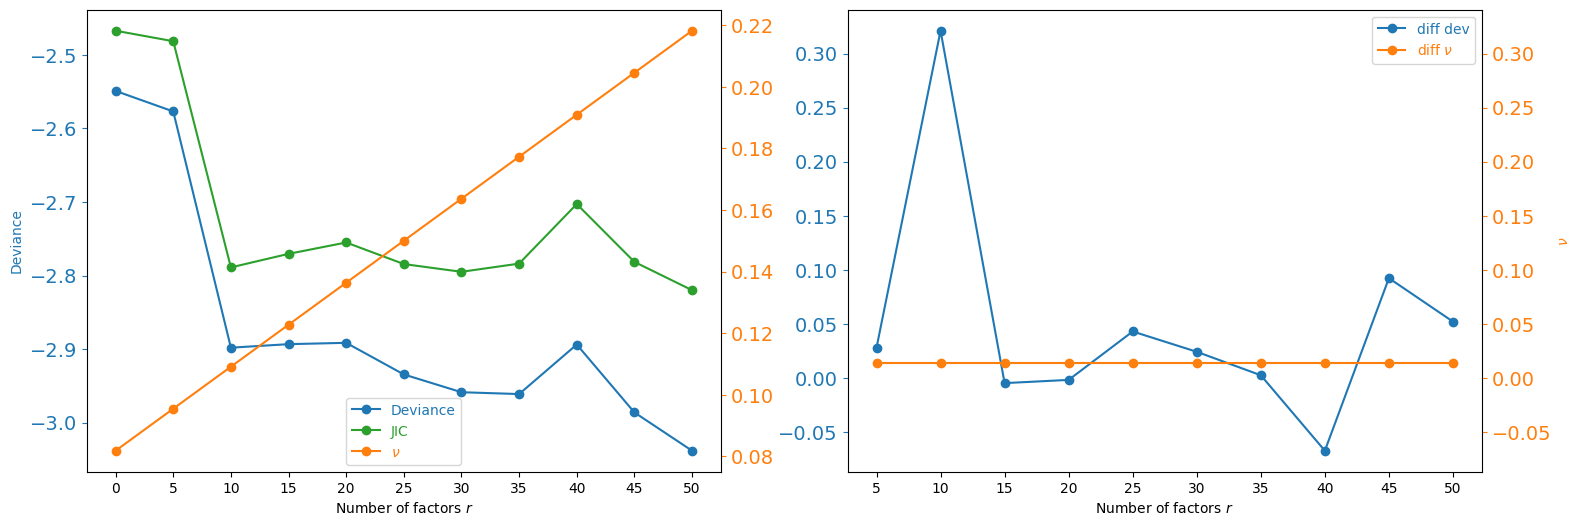

In [4]:
from causarray import estimate_r, plot_r
# df_r = estimate_r(Y, X, A, np.arange(5,55,5))
# df_r.to_csv('perturbseq-r.csv', index=False)
df_r = pd.read_csv('perturbseq-r.csv')
fig = plot_r(df_r)

### Estimate unmeasured confounders

We run **GCATE** with the selected *r* to estimate latent factors that capture
unmeasured confounders (e.g. cell-cycle phase, technical variation).
The estimated factors are appended to the covariate matrix before calling `LFC`.

In [5]:
r = 10
res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True,
    kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
    kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
)
U = res_2['U']
print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM (fast)...'


'Estimating initial coefficients with GLMs...'
'Fitting nb GLM (fast)...'


{'kwargs_es': {'max_iters': 30,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([ 1.11673516,  1.06870944,  1.16716468, ..., 12.58818245,
       16.46897663,  1.70852614], shape=(3221,)),
                'family': 'nb',
                'size_factor': array([0.53193358, 0.87362742, 1.2235467 , ..., 0.5593801 , 0.73025856,
       0.77857223], shape=(2926,))},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,
               'warmup_iters': 0}}
'Fitting GCATE (step 1)...'


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:07<?, ?it/s, nll=1.71]

...

 97%|█████████▋| 29/30 [00:15<00:00,  2.62it/s, nll=1.72]

 97%|█████████▋| 29/30 [00:15<00:00,  2.62it/s, nll=1.72]

100%|██████████| 30/30 [00:15<00:00,  2.61it/s, nll=1.72]

100%|██████████| 30/30 [00:15<00:00,  1.94it/s, nll=1.72]


Step 1  -- epochs: 29,  best NLL: 1.705777
Step 2  -- epochs: 29,  best NLL: 1.722559


### Estimate log-fold change based on counterfactuals

Next, we apply causarray to estimate the causal effects of perturbations on gene expression. Here the 106 GFP control cells and the perturbation groups (median 89 cells) are approximately balanced. We therefore use pooled variance to retain power in this relatively small comparison. This is a dataset-specific choice: unequal variance remains preferable when arm sizes or effective sample sizes are meaningfully unbalanced, when pseudo-outcome variability differs between arms, and for the Replogle and case-control tutorials.

In [6]:
offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors
df_res, estimation = LFC(Y, np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='pooled', verbose=True)

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351], shape=(2926,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
'Fit outcome models...'


'Fitting nb GLM (fast)...'


('Fast GLM coefficients exceed bound (max|B|=1.53e+05 > 1e+04); falling back '
 'to statsmodels...')
'Estimating dispersion parameter...'
'Fitting poisson GLM with offset...'


'Fitting nb GLM with offset...'


  0%|          | 0/3221 [00:00<?, ?it/s]

...

 21%|██        | 6/29 [00:00<00:00, 49.07it/s]

 45%|████▍     | 13/29 [00:00<00:00, 57.64it/s]

 69%|██████▉   | 20/29 [00:00<00:00, 60.22it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 60.20it/s]

100%|██████████| 29/29 [00:00<00:00, 59.09it/s]

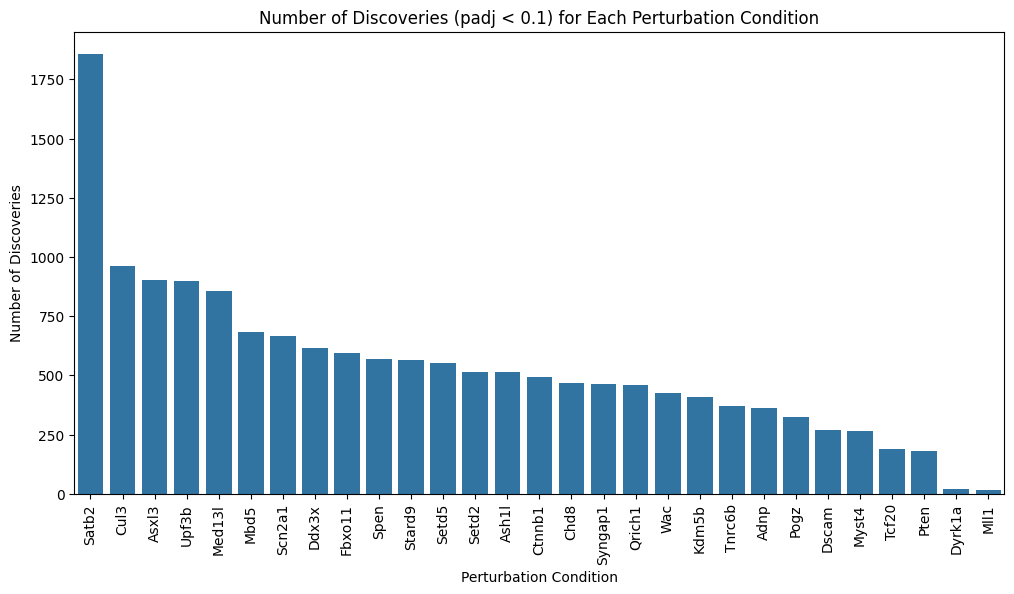

Total significant gene-perturbation pairs (padj < 0.1): 15,456
Perturbation  Count
       Satb2   1858
        Cul3    962
       Asxl3    901
       Upf3b    899
      Med13l    855
        Mbd5    682
      Scn2a1    664
       Ddx3x    616
      Fbxo11    593
        Spen    567
      Stard9    566
       Setd5    552
       Setd2    516
       Ash1l    512
      Ctnnb1    491
        Chd8    469
     Syngap1    462
      Qrich1    459
         Wac    424
       Kdm5b    410
      Tnrc6b    371
        Adnp    364
        Pogz    326
       Dscam    270
       Myst4    264
       Tcf20    187
        Pten    179
      Dyrk1a     20
        Mll1     17


,negative_fraction,median_tau,significant,significant_negative,significant_positive
trt,,,,,
Med13l,0.668115,-0.097780,855,653,202
Scn2a1,0.667495,-0.081455,664,543,121
Mbd5,0.665011,-0.078835,682,536,146
Upf3b,0.663148,-0.083435,899,715,184
Satb2,0.661596,-0.142076,1858,1398,460
Setd5,0.659112,-0.082058,552,458,94
Chd8,0.646383,-0.063514,469,374,95
Ctnnb1,0.645141,-0.062003,491,371,120
Asxl3,0.643589,-0.073545,901,696,205


In [7]:
# Filter the results for significant discoveries
significant_discoveries = df_res[df_res['padj'] < 0.1]

# Count the number of discoveries for each perturbation condition
discovery_counts = significant_discoveries['trt'].value_counts().reset_index()
discovery_counts.columns = ['Perturbation', 'Count']

# Plot the number of discoveries for each perturbation condition
plt.figure(figsize=(12, 6))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Number of Discoveries (padj < 0.1) for Each Perturbation Condition')
plt.xlabel('Perturbation Condition')
plt.ylabel('Number of Discoveries')
plt.show()
print(f"Total significant gene-perturbation pairs (padj < 0.1): {len(significant_discoveries):,}")
print(discovery_counts.to_string(index=False))

direction = df_res.assign(
    significant=df_res['padj'] < 0.1,
    significant_negative=(df_res['padj'] < 0.1) & (df_res['tau'] < 0),
    significant_positive=(df_res['padj'] < 0.1) & (df_res['tau'] > 0),
).groupby('trt').agg(
    negative_fraction=('tau', lambda value: (value < 0).mean()),
    median_tau=('tau', 'median'),
    significant=('significant', 'sum'),
    significant_negative=('significant_negative', 'sum'),
    significant_positive=('significant_positive', 'sum'),
).sort_values('negative_fraction', ascending=False)
display(direction)

### Propensity-score and positivity diagnostics

Positivity requires treated and control cells with comparable covariates. Each perturbation is scored against the shared controls with a five-fold out-of-fold logistic model using `class_weight='balanced'`, matching the model `LFC` uses internally, so an overfit model cannot flatter its own separation. The table reports histogram overlap, the fraction of scores outside `[0.05, 0.95]`, and the effective sample size (ESS) of the inverse-probability weights. For calibrated probabilities instead, pass `class_weight=None` here and `ps_class_weight=None` to `LFC`.

,treatment,n_treated,overlap_ratio,outside_overlap_fraction,ess_control_fraction,ess_treated_fraction,brier_score
18,Satb2,51,0.164,0.140,0.395,0.714,0.097
11,Mbd5,119,0.303,0.049,0.365,0.445,0.135
12,Med13l,75,0.313,0.017,0.699,0.458,0.149
27,Upf3b,100,0.318,0.029,0.640,0.699,0.135
2,Asxl3,130,0.319,0.030,0.552,0.865,0.134
19,Scn2a1,93,0.334,0.030,0.644,0.570,0.148
20,Setd2,76,0.335,0.011,0.592,0.758,0.174
17,Qrich1,86,0.362,0.000,0.761,0.573,0.170


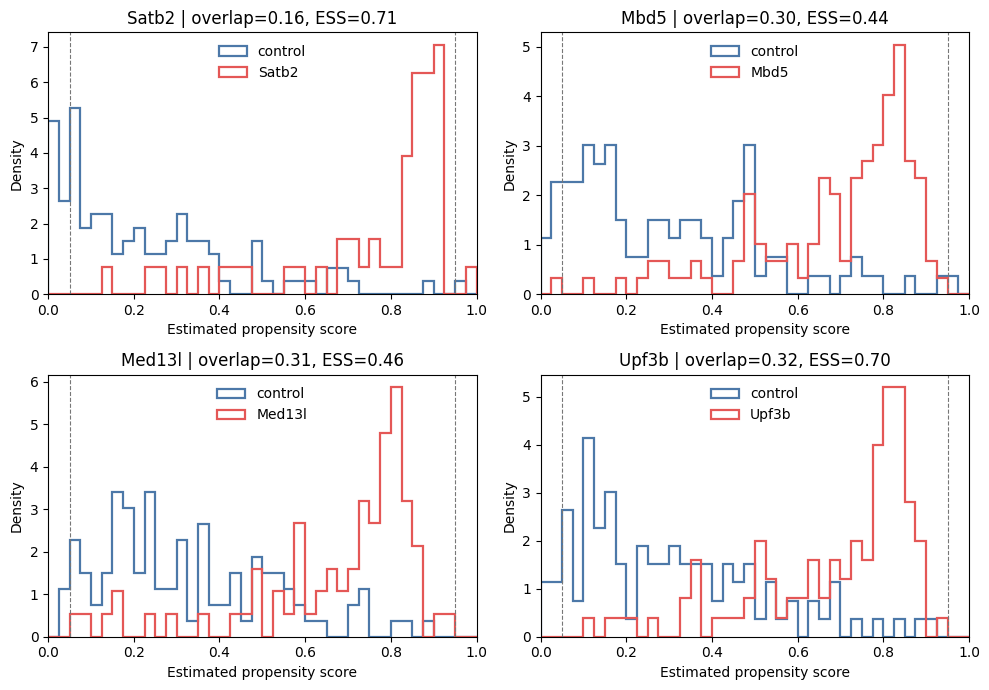

In [8]:
W_A = np.c_[X_A, U]
pi_oof = estimate_propensity_scores(
    A, W_A, K=5, class_weight='balanced', random_state=0,
)
# clip_bounds=None: these are raw out-of-fold scores, nothing has been clipped yet.
ps_summary = summarize_propensity_scores(A, pi_oof, clip_bounds=None)
display(
    ps_summary.sort_values('overlap_ratio')
    [['treatment', 'n_treated', 'overlap_ratio', 'outside_overlap_fraction',
      'ess_control_fraction', 'ess_treated_fraction', 'brier_score']]
    .head(8).round(3)
)

weakest = ps_summary.nsmallest(4, 'overlap_ratio')['treatment'].tolist()
fig, axes, _ = plot_propensity_scores(A, pi_oof, treatments=weakest, clip_bounds=None)
plt.show()

Comparing the training Brier score with the out-of-fold one shows how much the propensity model overfits. Stronger regularization (say `C=0.1`) is worth adopting only when it lowers the *out-of-fold* Brier score — making the histograms overlap more is not by itself an improvement. Class-balanced scores are not calibrated to the observed treatment prevalence, so assess calibration separately with `class_weight=None`.

In [9]:
pi_train = estimate_propensity_scores(
    A, W_A, K=1, class_weight='balanced', random_state=0,
)
ps_train = summarize_propensity_scores(A, pi_train)
pi_oof_regularized = estimate_propensity_scores(
    A, W_A, K=5, C=0.1, class_weight='balanced', random_state=0,
)
ps_regularized = summarize_propensity_scores(A, pi_oof_regularized)
overfit_check = ps_train[['treatment', 'brier_score']].rename(
    columns={'brier_score': 'brier_train_C1'}
).merge(
    ps_summary[['treatment', 'overlap_ratio', 'brier_score']].rename(
        columns={'brier_score': 'brier_oof_C1'}), on='treatment'
).merge(
    ps_regularized[['treatment', 'overlap_ratio', 'brier_score']].rename(
        columns={'overlap_ratio': 'overlap_ratio_C01', 'brier_score': 'brier_oof_C01'}),
    on='treatment',
)
display(overfit_check.sort_values('overlap_ratio').head(10))

# Reuse fitted outcome models for a propensity sensitivity analysis.
# df_oof, _ = LFC(Y, np.c_[X, U], A, W_A, offset=offsets,
#                 Y_hat=estimation['Y_hat'], pi_hat=pi_oof, usevar='pooled')

,treatment,brier_train_C1,overlap_ratio,brier_oof_C1,overlap_ratio_C01,brier_oof_C01
18,Satb2,0.075466,0.164077,0.096756,0.288198,0.146275
11,Mbd5,0.116343,0.303393,0.134982,0.452275,0.178107
12,Med13l,0.131976,0.313208,0.148720,0.448176,0.187060
27,Upf3b,0.118060,0.317547,0.135306,0.446415,0.182605
2,Asxl3,0.117547,0.319448,0.133628,0.512046,0.184543
19,Scn2a1,0.129479,0.333739,0.147952,0.502029,0.190732
20,Setd2,0.147268,0.335402,0.173702,0.514151,0.203231
17,Qrich1,0.148151,0.362440,0.169654,0.544756,0.210978
6,Ddx3x,0.146036,0.367925,0.175877,0.537736,0.206478
9,Fbxo11,0.151591,0.394612,0.168791,0.566633,0.209796


**Reading the table.** The overlap ratio is descriptive, not a pass/fail threshold. Here 28 of the 29 perturbations sit above 0.25, which is compatible with useful common support. Satb2 is the exception: overlap 0.164, 14.0% of its scores outside `[0.05, 0.95]`, and a control ESS of only 39.5% of the nominal control count. Its estimates deserve more caution than the rest, which makes it the natural candidate for the treatment-specific tuning below.

### Are the latent factors associated with treatment?

For each latent factor, an omnibus one-way ANOVA tests equality across control and perturbation groups. Because large cell counts make small differences significant, treatment-explained variance (`eta2`) is reported with BH-adjusted p-values. The heatmap shows standardized differences from control for individual perturbations.

,factor,F,pvalue,eta2,padj
0,U1,0.330944,0.999727,0.003303,1.00000
1,U2,0.224609,0.999996,0.002244,1.00000
2,U3,0.192696,0.999999,0.001926,1.00000
3,U4,0.240109,0.999991,0.002399,1.00000
4,U5,0.128538,1.000000,0.001286,1.00000
5,U6,0.304299,0.999885,0.003038,1.00000
6,U7,1.471180,0.050073,0.014518,0.50073
7,U8,1.105642,0.318305,0.010950,1.00000
8,U9,1.139224,0.277604,0.011279,1.00000
9,U10,0.742114,0.838668,0.007377,1.00000


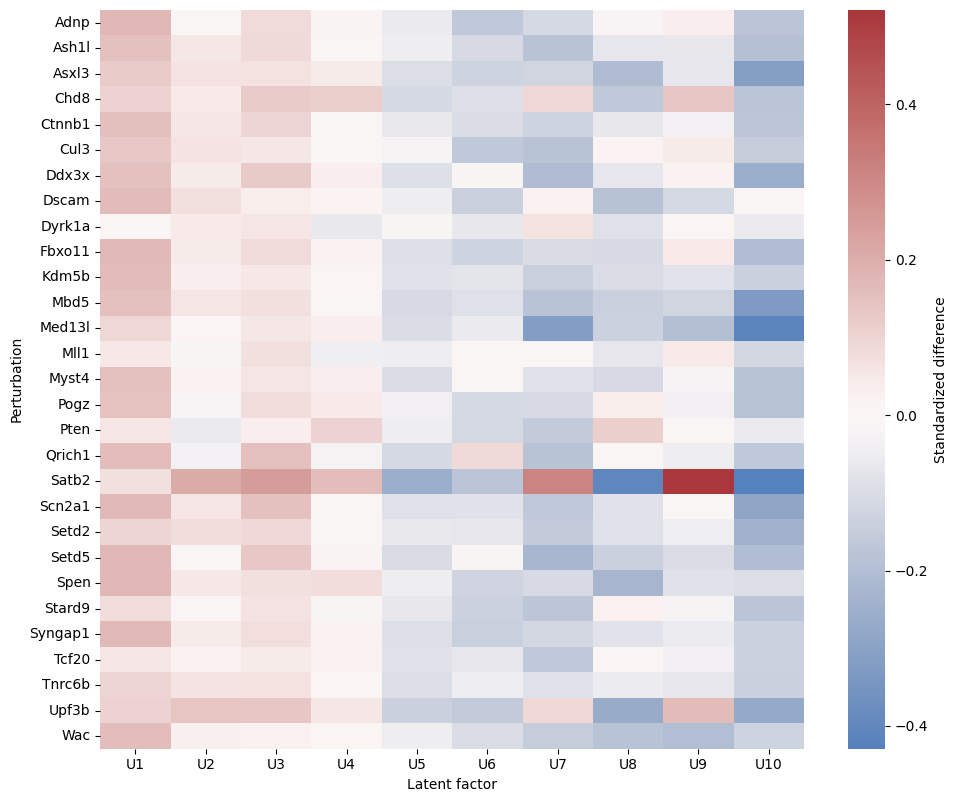

In [10]:
labels = np.full(A.shape[0], 'control', dtype=object)
for j, pert in enumerate(A.columns):
    labels[A.iloc[:, j].to_numpy() == 1] = pert
group_names = ['control', *A.columns.tolist()]

u_tests = []
for k in range(U.shape[1]):
    grouped = [U[labels == group, k] for group in group_names]
    f_stat, pvalue = stats.f_oneway(*grouped)
    grand_mean = U[:, k].mean()
    ss_between = sum(len(values) * (values.mean() - grand_mean) ** 2 for values in grouped)
    eta2 = ss_between / np.sum((U[:, k] - grand_mean) ** 2)
    u_tests.append({'factor': f'U{k + 1}', 'F': f_stat, 'pvalue': pvalue, 'eta2': eta2})
u_tests = pd.DataFrame(u_tests)
u_tests['padj'] = multipletests(u_tests['pvalue'], method='fdr_bh')[1]
display(u_tests)

ctrl = labels == 'control'
smd = pd.DataFrame(index=A.columns, columns=u_tests['factor'], dtype=float)
for pert in A.columns:
    case = labels == pert
    pooled_sd = np.sqrt((U[case].var(axis=0, ddof=1) + U[ctrl].var(axis=0, ddof=1)) / 2)
    smd.loc[pert] = (U[case].mean(axis=0) - U[ctrl].mean(axis=0)) / pooled_sd
plt.figure(figsize=(10, max(6, 0.28 * len(smd))))
sns.heatmap(smd, cmap='vlag', center=0, cbar_kws={'label': 'Standardized difference'})
plt.xlabel('Latent factor')
plt.ylabel('Perturbation')
plt.tight_layout()
plt.show()

### Treatment-specific association diagnostics

These helpers apply the same shared-control comparison to observed covariates and latent factors. Spearman correlation captures monotone association, while the standardized mean difference puts it on a familiar effect-size scale. P-values are BH-adjusted across every treatment-by-covariate pair by default; pass `bh_scope='per_treatment'` to adjust within each treatment instead. No cutoff or drop decision is applied for you.

Log-library size is strongly associated with several perturbations, but it is a prespecified technical adjustment and we keep it — association alone is not a reason to drop a covariate, and dropping a genuine confounder to improve an overlap plot trades a visible problem for an invisible one. Among the latent factors, Satb2--U9 has the largest imbalance (Spearman $\rho \approx 0.247$, SMD $\approx 0.521$). We drop it below purely as a one-factor sensitivity check.

,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant,n_tests_in_family
217,Satb2,log_library_size,observed,106,51,-0.620601,4.352985e-18,1.388602e-15,-1.670432,False,319
133,Mbd5,log_library_size,observed,106,119,-0.525168,2.377952e-17,3.792833e-15,-1.196548,False,319
25,Asxl3,log_library_size,observed,106,130,-0.501171,2.061826e-16,2.192409e-14,-1.147867,False,319
325,Upf3b,log_library_size,observed,106,100,-0.524464,5.917208e-16,4.718973e-14,-1.193805,False,319
229,Scn2a1,log_library_size,observed,106,93,-0.479169,8.091610e-13,5.162447e-11,-1.070860,False,319
145,Med13l,log_library_size,observed,106,75,-0.491124,2.226940e-12,1.183990e-10,-1.072918,False,319
241,Setd2,log_library_size,observed,106,76,-0.450423,1.771080e-10,8.071064e-09,-0.971646,False,319
253,Setd5,log_library_size,observed,106,71,-0.438344,1.046791e-09,3.710293e-08,-0.952658,False,319
13,Ash1l,log_library_size,observed,106,122,-0.390531,1.003845e-09,3.710293e-08,-0.806900,False,319
109,Fbxo11,log_library_size,observed,106,111,-0.394344,1.730357e-09,5.519838e-08,-0.844210,False,319


,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant,n_tests_in_family
226,Satb2,U9,latent,106,51,0.247280,0.001795,0.022898,0.520999,False,319
227,Satb2,U10,latent,106,51,-0.190262,0.016997,0.154919,-0.429236,False,319
155,Med13l,U10,latent,106,75,-0.205422,0.005534,0.060877,-0.411375,False,319
225,Satb2,U8,latent,106,51,-0.242478,0.002215,0.027178,-0.406490,False,319
143,Mbd5,U10,latent,106,119,-0.175056,0.008499,0.087460,-0.328204,False,319
152,Med13l,U7,latent,106,75,-0.101960,0.172006,0.883705,-0.319727,False,319
35,Asxl3,U10,latent,106,130,-0.160805,0.013386,0.125593,-0.314906,False,319
224,Satb2,U7,latent,106,51,0.206467,0.009477,0.094470,0.313717,False,319
239,Scn2a1,U10,latent,106,93,-0.148151,0.036771,0.308679,-0.284932,False,319
335,Upf3b,U10,latent,106,100,-0.163987,0.018508,0.163999,-0.272426,False,319


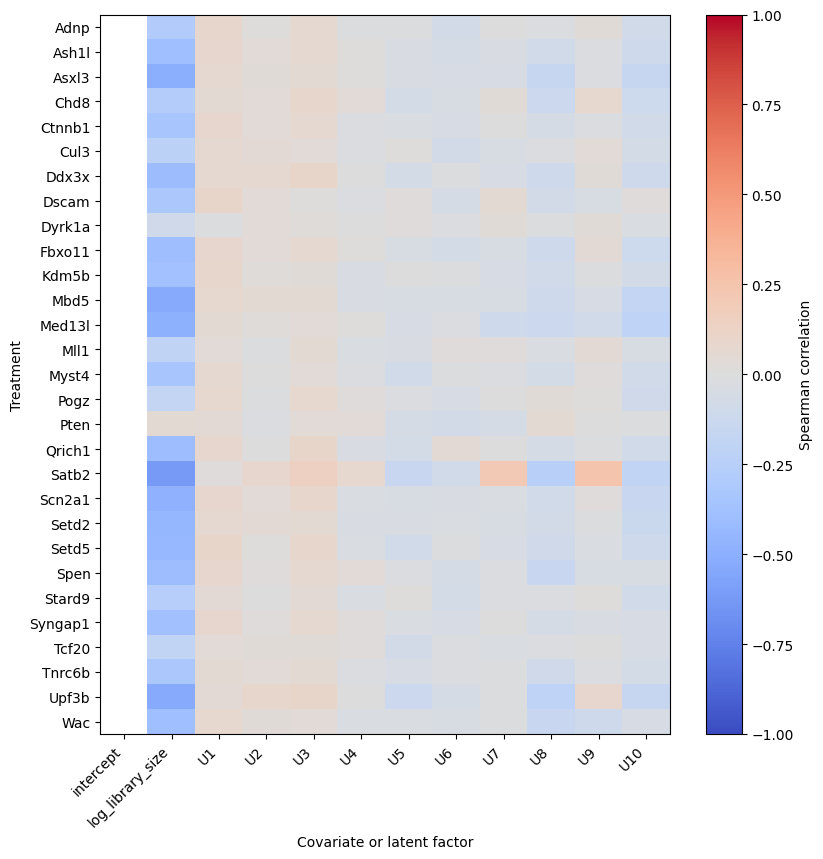

In [11]:
factor_names = [f'U{k + 1}' for k in range(U.shape[1])]
propensity_names = ['intercept', 'log_library_size', *factor_names]
propensity_types = ['observed', 'observed', *(['latent'] * U.shape[1])]
association_summary = summarize_treatment_associations(
    A, W_A, covariate_names=propensity_names,
    covariate_types=propensity_types,
)
observed_associations = association_summary.query("covariate_type == 'observed' and not constant")
latent_associations = association_summary.query("covariate_type == 'latent'").copy()
display(observed_associations.sort_values('padj').head(10))
display(
    latent_associations.assign(abs_smd=lambda frame: frame['standardized_mean_difference'].abs())
    .sort_values('abs_smd', ascending=False).drop(columns='abs_smd').head(10)
)
fig, ax = plot_treatment_associations(association_summary)
plt.show()

#### Tuning Satb2's propensity model

Propensity scores are fit one treatment at a time against the shared controls, so you can change the model for a single perturbation and leave the other 28 untouched. `refit_propensity_scores` refits only the treatments you name and returns an audit table next to the updated scores. Three alternatives for Satb2:

- **drop U9** — remove the most imbalanced latent factor;
- **10x library penalty** — keep every covariate, but apply ten times the usual L2 penalty to standardized log-library size (implemented by dividing that column by $\sqrt{10}$ during both fitting and prediction);
- **Satb2 C=0.1** — keep every covariate and shrink all of them more strongly.

Out-of-fold scores drive the overlap diagnostics; the analysis scores then reuse `estimation['Y_hat']`, so no outcome model is refitted.

,model,n_retained,penalty_factors,degenerate_design,score_std
0,drop U9,11,{},False,0.322
0,10x library penalty,12,{'log_library_size': 10.0},False,0.237
0,Satb2 C=0.1,12,{},False,0.239


,model,overlap_ratio,outside_overlap_fraction,ess_control_fraction,ess_treated_fraction,brier_score
18,all factors,0.164,0.140,0.395,0.714,0.097
18,drop U9,0.183,0.134,0.403,0.712,0.096
18,10x library penalty,0.268,0.019,0.723,0.792,0.137
18,Satb2 C=0.1,0.288,0.006,0.627,0.813,0.146


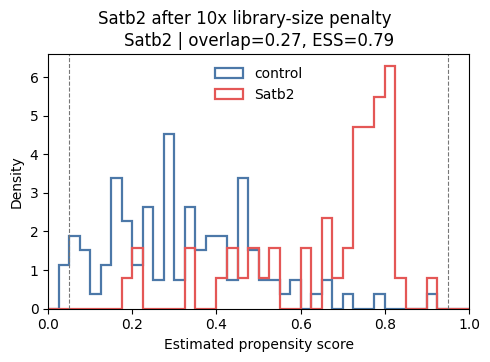

  0%|          | 0/29 [00:00<?, ?it/s]

 21%|██        | 6/29 [00:00<00:00, 50.46it/s]

 45%|████▍     | 13/29 [00:00<00:00, 57.75it/s]

 69%|██████▉   | 20/29 [00:00<00:00, 61.03it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 60.95it/s]

...

 45%|████▍     | 13/29 [00:00<00:00, 59.72it/s]

 69%|██████▉   | 20/29 [00:00<00:00, 62.40it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 61.23it/s]

100%|██████████| 29/29 [00:00<00:00, 60.58it/s]

,model,effect_correlation,median_absolute_change,discoveries,discoveries_all
0,drop U9,1.000,0.004,1852,1858
1,10x library penalty,0.997,0.012,1775,1858
2,Satb2 C=0.1,0.982,0.024,1568,1858


In [12]:
# Three treatment-specific alternatives for Satb2. Each refits Satb2 alone and
# leaves the other 28 perturbations' scores exactly as they were.
satb2_variants = {
    'drop U9': dict(drop_by_treatment={'Satb2': ['U9']}),
    '10x library penalty': dict(
        penalty_factors_by_treatment={'Satb2': {'log_library_size': 10}}),
    'Satb2 C=0.1': dict(drop_by_treatment={'Satb2': []}, C=0.1),
}


def refit_satb2(pi_hat, K, **kwargs):
    return refit_propensity_scores(
        A, W_A, pi_hat=pi_hat, covariate_names=propensity_names, K=K,
        class_weight='balanced', random_state=0, **kwargs,
    )


# Out-of-fold scores, used only for the overlap diagnostics.
oof_variants, audits = {}, []
for name, options in satb2_variants.items():
    scores, audit = refit_satb2(pi_oof, 5, **options)
    oof_variants[name] = scores
    audits.append(audit.assign(model=name))
display(
    pd.concat(audits)
    [['model', 'n_retained', 'penalty_factors', 'degenerate_design', 'score_std']]
    .round(3)
)

satb2_overlap = pd.concat([
    summarize_propensity_scores(A, scores, clip_bounds=None)
    .query("treatment == 'Satb2'").assign(model=name)
    for name, scores in {'all factors': pi_oof, **oof_variants}.items()
])[['model', 'overlap_ratio', 'outside_overlap_fraction',
    'ess_control_fraction', 'ess_treated_fraction', 'brier_score']]
display(satb2_overlap.round(3))

fig, axes, _ = plot_propensity_scores(
    A, oof_variants['10x library penalty'], treatments=['Satb2'], clip_bounds=None,
)
fig.suptitle('Satb2 after 10x library-size penalty', y=1.02)
plt.show()

# Analysis scores reuse the cached outcome model, so no outcome model is refitted.
satb2_effects = (
    df_res.query("trt == 'Satb2'")[['gene_names', 'tau', 'padj']]
    .rename(columns={'tau': 'tau_all', 'padj': 'padj_all'})
)
comparison = []
for name, options in satb2_variants.items():
    pi_analysis, _ = refit_satb2(estimation['pi_hat_raw'], 1, **options)
    df_alt, _ = LFC(
        Y, np.c_[X, U], A, W_A, offset=offsets, usevar='pooled',
        Y_hat=estimation['Y_hat'], pi_hat=pi_analysis,
    )
    merged = satb2_effects.merge(
        df_alt.query("trt == 'Satb2'")[['gene_names', 'tau', 'padj']], on='gene_names',
    )
    comparison.append({
        'model': name,
        'effect_correlation': merged[['tau_all', 'tau']].corr().iloc[0, 1],
        'median_absolute_change': (merged['tau_all'] - merged['tau']).abs().median(),
        'discoveries': int((merged['padj'] < 0.1).sum()),
    })
display(
    pd.DataFrame(comparison)
    .assign(discoveries_all=int((satb2_effects['padj_all'] < 0.1).sum()))
    .round(3)
)

**What the three variants show.** Dropping U9 barely moves anything: overlap goes from 0.164 to 0.183 and the effects correlate at 1.000. The two shrinkage options buy real overlap — the 10x library penalty reaches 0.268 and lifts control ESS from 0.395 to 0.723, and `C=0.1` reaches 0.288 with almost nothing left outside `[0.05, 0.95]`. Both cost calibration: the out-of-fold Brier score rises from 0.097 to 0.137 and 0.146, so the smoother scores are buying overlap with bias rather than predicting treatment better.

Effects stay close throughout (correlation 0.997 and 0.982) while discoveries move from 1,858 to 1,775 and 1,568. Stable effects with gently falling power and worse calibration is what a well-behaved sensitivity analysis looks like. Report the variants alongside the primary fit so readers can see the spread — and if a conclusion holds under only one propensity specification, that is worth knowing before you rely on it.